Import Libraries

In [4]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

Load Dataset

In [5]:
df=pd.read_csv('cleaned_vehicle_sales.csv')
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,...,sellingprice,saledate,vehicle_age,price_difference,price_ratio,sale_year,sale_month,sale_day,sale_weekday,sale_quarter
0,2015,Kia,Sorento,LX,Suv,Automatic,5xyktca69fg566472,ca,5.0,16639.0,...,21500.0,2014-12-16 04:30:00+00:00,-1,1000.0,1.048780,2014,December,16,Tuesday,4
1,2015,Kia,Sorento,LX,Suv,Automatic,5xyktca69fg561319,ca,5.0,9393.0,...,21500.0,2014-12-16 04:30:00+00:00,-1,700.0,1.033654,2014,December,16,Tuesday,4
2,2014,Bmw,3 Series,328i SULEV,Sedan,Automatic,wba3c1c51ek116351,ca,45.0,1331.0,...,30000.0,2015-01-14 20:30:00+00:00,1,-1900.0,0.940439,2015,January,14,Wednesday,1
3,2015,Volvo,S60,T5,Sedan,Automatic,yv1612tb4f1310987,ca,41.0,14282.0,...,27750.0,2015-01-28 20:30:00+00:00,0,250.0,1.009091,2015,January,28,Wednesday,1
4,2014,Bmw,6 Series Gran Coupe,650i,Sedan,Automatic,wba6b2c57ed129731,ca,43.0,2641.0,...,67000.0,2014-12-18 04:30:00+00:00,0,1000.0,1.015152,2014,December,18,Thursday,4


STEP 1 Define Significance Level

In [6]:
alpha=0.05

Meaning:

1. p-value < 0.05 → Reject H₀
2. p-value ≥ 0.05 → Fail to reject H₀

1. Hypothesis Test 1

Business Question

Does the transmission type significantly affect the selling price of vehicles?

Hypotheses

Null Hypothesis (H₀):

There is no significant difference in the selling price distributions among different transmission types.

Alternative Hypothesis (H₁):

There is a significant difference in the selling price distributions among different transmission types.

Step 1

Separate Automatic and Manual vehicles 

In [7]:
automatic= df[df['transmission']== 'Automatic']['sellingprice']
manual= df[df['transmission']=='Manual']['sellingprice']
unknown=df[df['transmission']=='Unknown']['sellingprice']

Step 2

Visualize

<Axes: xlabel='transmission', ylabel='sellingprice'>

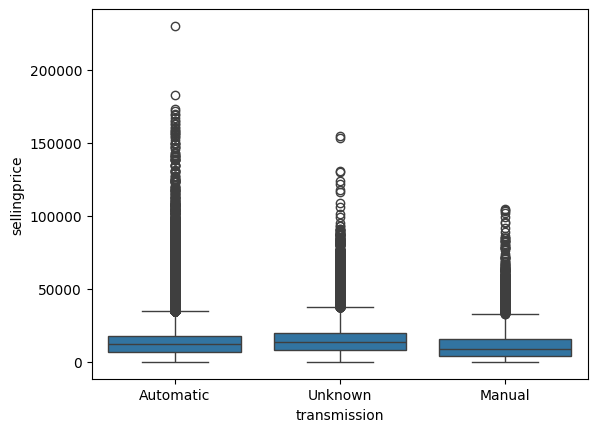

In [8]:
sns.boxplot(x='transmission', y='sellingprice', data=df)

Step 3

Normality Check

In [9]:
print(df['transmission'].nunique())

3


In [10]:
print(len(automatic))

475904


In [11]:
print(len(manual))

17544


In [12]:
stats.shapiro(automatic.sample(5000, random_state=42))
stats.shapiro(manual.sample(5000, random_state=42))
stats.shapiro(unknown.sample(5000, random_state=42))

ShapiroResult(statistic=np.float64(0.8851876238957798), pvalue=np.float64(1.457605728836917e-51))

Interpretation-

Since the p-value (1.45 × 10⁻⁵¹) is much smaller than the significance level (α = 0.05), the null hypothesis of normality is rejected. Therefore, the selling price data does not follow a normal distribution.

Because the normality assumption is violated, Kruskal–Wallis Test was selected instead of an independent samples t-test.

Step 4

Kruskal–Wallis Test

In [13]:
from scipy.stats import kruskal

groups = [
    group['sellingprice'].dropna().values
    for _, group in df.groupby('transmission')
]

H, p = kruskal(*groups)

print("H Statistic:", H)
print("p-value:", p)

H Statistic: 3247.8952708915344
p-value: 0.0


Decision

Since the p-value (1.10 × 10⁻¹⁸⁷) is less than 0.05, the null hypothesis is rejected.

In [14]:
df['transmission'].value_counts(dropna=False)

transmission
Automatic    475904
Unknown       65351
Manual        17544
Name: count, dtype: int64

In [15]:
df.groupby('transmission')['sellingprice'].agg(
    ['count', 'mean', 'median']
)

,count,mean,median
transmission,,,
Automatic,475904,13540.406866,12100.0
Manual,17544,11211.448358,8600.0
Unknown,65351,14772.304142,13500.0


Step 5 

Interpretation

In [16]:
if p < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


Decision

Since the p-value < 0.05, the null hypothesis is rejected.

Statistical Conclusion

There is sufficient statistical evidence to conclude that at least one transmission category has a significantly different selling price distribution compared to the others.

Important-

The Kruskal–Wallis test only tells you that a difference exists somewhere.

It does not tell you which groups differ.

You now need a post-hoc analysis.

Step 6 

post-hoc analysis

Step 6.1: Pairwise Comparisons

Run three Mann–Whitney U tests:

Automatic vs Manual

In [17]:
from scipy.stats import mannwhitneyu

auto = df[df['transmission']=='Automatic']['sellingprice']
manual = df[df['transmission']=='Manual']['sellingprice']

u, p = mannwhitneyu(auto, manual)

print(u)
print(p)

4995930549.5
0.0


Automatic VS Unknown

In [18]:
unknown = df[df['transmission']=='Unknown']['sellingprice']

u, p = mannwhitneyu(auto, unknown)

print(u)
print(p)

14286620744.0
1.372947476223241e-249


Manual vs Unknown

In [19]:
u, p = mannwhitneyu(manual, unknown)

print(u)
print(p)

424935183.0
0.0


Step 6.2 : Bonferroni Correction

Since there are 3 comparisons, use:

In [20]:
alpha = 0.05 / 3
print(alpha)

0.016666666666666666


Now compare each pairwise p-value against 0.0167, not 0.05.

All p-values are less than 0.0167, so all pairwise comparisons are statistically significant.

Final Decision

The null hypothesis is rejected.

Transmission type has a statistically significant effect on vehicle selling prices.

Business Insight

The statistical analysis shows that selling price distributions differ significantly across transmission categories. This indicates that transmission type is an important characteristic influencing vehicle valuation and should be considered when pricing vehicles or analyzing market demand.

Step 7 Effect Size Calculation

Statistical significance alone does not indicate the magnitude of the observed differences.

Therefore, Epsilon Squared (ε²) was calculated to measure the practical significance of the Kruskal–Wallis test.

I used the Kruskal–Wallis H Test, the recommended effect size is Epsilon Squared (ε²).

Step 7.1 Formula

The effect size is calculated as:

ε
2
= H-k+1 /n-k

	​


Where:

H = Kruskal–Wallis H statistic,
k = Number of groups,
n = Total number of observations

Step 7.2 Calculation

In [21]:
H = 3247.8952708915344

k = df['transmission'].nunique()     # Number of groups

n = len(df)                          # Total observations

epsilon_sq = (H - k + 1) / (n - k)

print("Effect Size (Epsilon Squared):", epsilon_sq)

Effect Size (Epsilon Squared): 0.005808730325362985


Step 7.3 Step 3: Interpretation

Use this guideline:

Epsilon Squared (ε²)

Interpretation
1. < 0.01-	Negligible Effect
2. 0.01 – 0.08	Small Effect
3. 0.08 – 0.26	Moderate Effect
4. > 0.26	Large Effect

The effect size is 0.005, indicating a negligible effect of transmission type on selling price.

What does it mean- 

It means:

Transmission type has a statistically detectable effect on selling price, but the magnitude of that effect is very small.

This often happens with very large datasets like yours (over 500,000 records).

With such a large sample:

Even very small differences can produce extremely small p-values.
The p-value tells you the difference is unlikely to be due to random chance.
The effect size tells you whether that difference is meaningful in practice.

2. Hypothesis Test 2

Business Question

Does vehicle condition affect selling price?

Since there are many condition levels, use One-Way ANOVA.

Step 1 Prepare groups

In [22]:
groups = [
    group['sellingprice'].values
    for _, group in df.groupby('condition')
]

f_stat, p=stats.f_oneway(*groups)
print(f_stat)
print(p)

5798.509148909637
0.0


Decision

Since the p-value < 0.05, the null hypothesis is rejected.

Statistical Conclusion

There is sufficient statistical evidence to conclude that the average selling price differs significantly across vehicle condition categories.

Business Insight

Vehicle condition has a statistically significant impact on resale value. Vehicles in better condition generally command higher selling prices, indicating that buyers place a premium on well-maintained vehicles.

Step 2 

ANOVA only tells you:

At least one group is different.

It does not tell you which condition categories differ.

The standard follow-up is a post-hoc test, typically:

Tukey's Honest Significant Difference (Tukey HSD)

In [23]:
#pip install statsmodels

In [24]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey= pairwise_tukeyhsd(
    endog=df['sellingprice'],
    groups= df['condition'],
    alpha=0.05
)
print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
group1 group2   meandiff  p-adj     lower       upper    reject
---------------------------------------------------------------
   1.0    2.0   1768.2745    0.0   1334.8714   2201.6776   True
   1.0    3.0   8352.1495    0.0   7869.1721   8835.1269   True
   1.0    4.0   13801.403    0.0  13365.5373  14237.2687   True
   1.0    5.0   20801.589    0.0  20322.2894  21280.8886   True
   1.0   11.0    581.3468    1.0  -2865.3007   4027.9944  False
   1.0   12.0   -102.3465    1.0  -3402.4512   3197.7583  False
   1.0   13.0   -368.2579    1.0    -3917.24   3180.7242  False
   1.0   14.0   -599.2553    1.0  -3385.1811   2186.6704  False
   1.0   15.0     -9.5943    1.0  -2698.8376   2679.6491  False
   1.0   16.0       463.1    1.0  -1961.1783   2887.3784  False
   1.0   17.0    151.7612    1.0  -1932.0233   2235.5456  False
   1.0   18.0    660.9198    1.0  -1155.9609   2477.8004  False
   1.0   19.0   1158.8666    0.0    755.

This will identify which specific condition levels have significantly different average selling prices.

Step 3 visualization

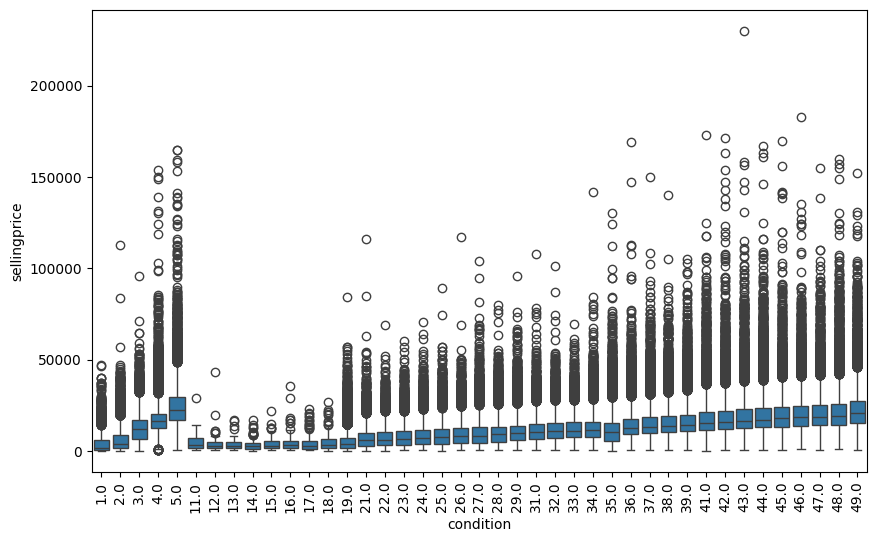

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='condition',
    y='sellingprice'
)
plt.xticks(rotation=90)
plt.show()

3. Hypothesis Test 3

Business Question

Do different body types have different selling prices?

Step 1 Prepare Groups

In [26]:
groups = [
    group['sellingprice'].values
    for _, group in df.groupby('body')
]

f_stat, stats.f_oneway(*groups)
print(f_stat)
print(p)

5798.509148909637
0.0


Decision- value of p <0.05 So there is significant difference between the average selling price and body.

So H0 is rejected

Step 2 Visualization

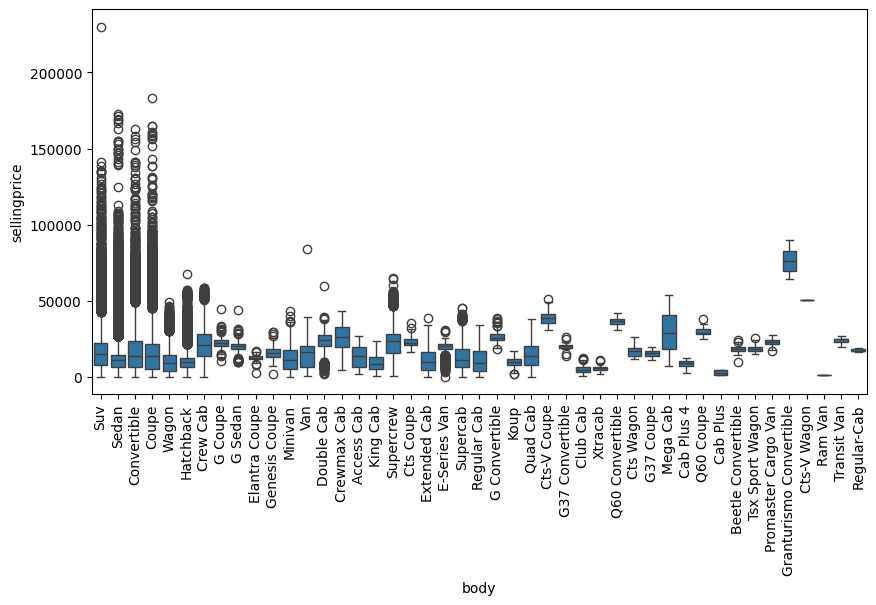

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,
x= 'body',
y='sellingprice')
plt.xticks(rotation=90)
plt.show()

Step 3 

ANOVA only tells you:

At least one group is different.

It does not tell you which condition categories differ.

The standard follow-up is a post-hoc test, typically:

Tukey's Honest Significant Difference (Tukey HSD)

In [28]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey= pairwise_tukeyhsd(
    endog=df['sellingprice'],
    groups= df['body'],
    alpha=0.05
)
print(tukey)

                       Multiple Comparison of Means - Tukey HSD, FWER=0.05                        
         group1                  group2           meandiff  p-adj     lower        upper    reject
--------------------------------------------------------------------------------------------------
             Access Cab      Beetle Convertible   4628.0122 0.1895    -556.3675    9812.392  False
             Access Cab                Cab Plus -10661.3946 0.9761  -28955.6018   7632.8127  False
             Access Cab              Cab Plus 4  -5169.7279    1.0  -20156.9264   9817.4706  False
             Access Cab                Club Cab  -8665.5519    0.0  -12116.9611  -5214.1426   True
             Access Cab             Convertible   4354.0695    0.0    2205.0242   6503.1147   True
             Access Cab                   Coupe   2441.4245 0.0053     304.4355   4578.4135   True
             Access Cab                Crew Cab   8162.6543    0.0    6024.2238  10301.0848   True
          

4. Hypothesis Test 4

Business Question

Is there a significant relationship between odometer and selling price?

Step 1 
Calculate Pearson correlation

In [29]:
r,p =stats.pearsonr(
    df['odometer'],
    df['sellingprice']
)

print(p)
print(r)

0.0
-0.5822925932432319


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Statistical Conclusion

There is a statistically significant negative correlation between odometer reading and vehicle selling price.

r = -0.5822

This indicates a moderate negative correlation.

This means:

As odometer reading increases, selling price decreases.
Vehicles with higher mileage generally have lower resale values.

Step 2 Effect size

For a Pearson Correlation Test, the correlation coefficient (r) itself is the effect size.

|r|= 0.5822 indicates a large effect size

Step 3 Visualization

<Axes: xlabel='odometer', ylabel='sellingprice'>

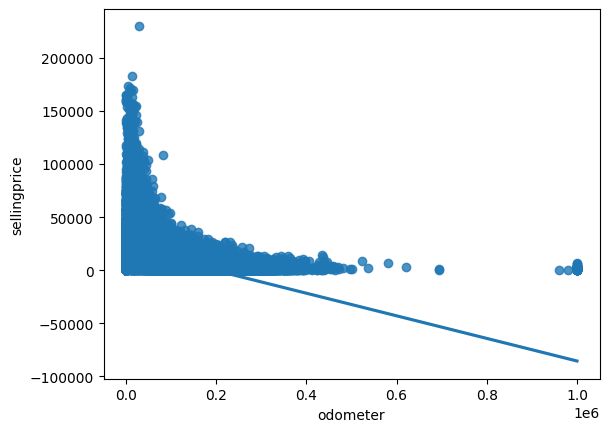

In [30]:
sns.regplot(
    data=df,
    x='odometer',
    y='sellingprice'
)

Interpretation:

Correlation coefficient (r)= -0.5882

p-value= 0.0

Direction (positive/negative)= negative

Strength (weak/moderate/strong)=  moderate

5. Hypothesis Test 5 

Business Question

Is the average selling price significantly different from the average MMR?

Step 1 use a paired t-test Because each vehicle has both values

In [31]:
t,p = stats.ttest_rel(
    df['sellingprice'],
    df['mmr']
)

print(t)
print(p)

-67.157085879278
0.0


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Statistical Conclusion

There is a stronog evidence that the average selling price is significantlly different from the avg mmr value

t-statistics = - 76.1571
The negative signs indicate the direction of the difference.


This test is based on: sellingprice - mmr

this shows that vehicles in my dataaset were generally solf for less than their MMR value

Step 2 visualization

<Axes: xlabel='mmr', ylabel='sellingprice'>

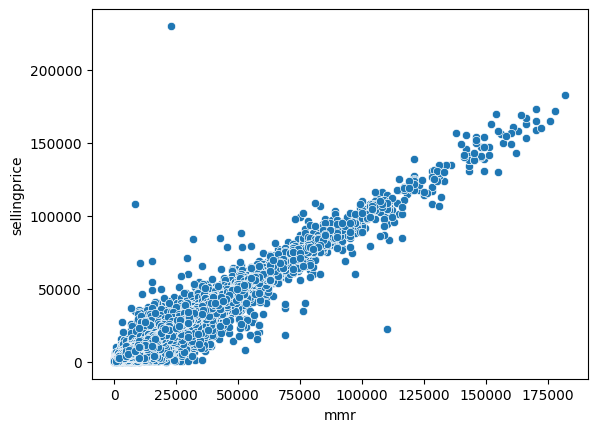

In [32]:
sns.scatterplot(
    data=df,
    x='mmr',
    y='sellingprice'
)

Step 3  Calculating Average Price Difference

In [33]:
print((df['sellingprice']-df['mmr']).mean())

-158.02119903578927


Conclusion- On average, vehicles sold for 158 RS below their MmR value.

6. Hypothesis Test 6 

Business Question

Do different states have different average selling prices?

Step 1 Group by state

In [34]:
groups = [
    group['sellingprice'].values
    for _, group in df.groupby('state')
]

f_stat, stats.f_oneway(*groups)

print('f_stat:', f_stat)
print('value of p:', p)

f_stat: 5798.509148909637
value of p: 0.0


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Step 2 Visualization

<Axes: xlabel='state', ylabel='sellingprice'>

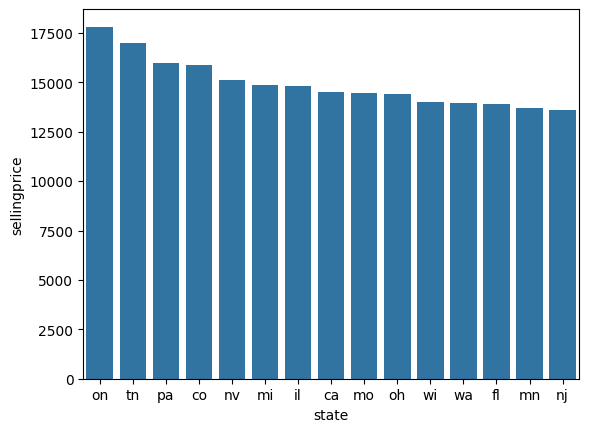

In [35]:
state_avg = (
    df.groupby('state')['sellingprice']
      .mean()
      .sort_values(ascending=False)
      .head(15)
      .reset_index()
)

sns.barplot(
    data=state_avg,
    x='state',
    y='sellingprice'
)

7. Hypothesis Test 7

Business Question

Do different vehicle brands have significantly different average selling prices?

Step 1 Prepare Groups

In [36]:
groups= [
    group['sellingprice'].values
    for _, group in df.groupby('make')
]

f_stat, stats.f_oneway(*groups)
print(f_stat)
print(p)

5798.509148909637
0.0


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Step 2 visualization

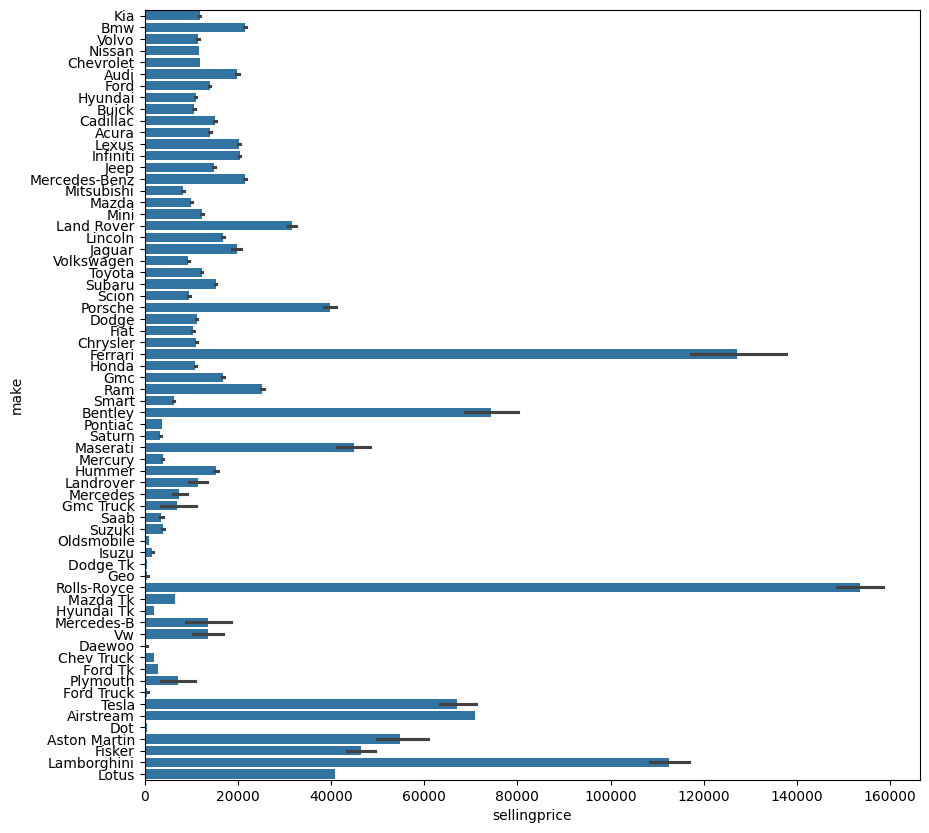

In [37]:
plt.figure(figsize=(10,10))
sns.barplot(data=df,
            x='sellingprice',
            y='make')
plt.show()

8. Hypothesis Test 8

Business Question

Do different sellers achieve different average selling prices?

Step 1 Prepare the Group

In [38]:
groups=[
    group['sellingprice'].values
    for _, group in df.groupby('seller')
]

f_stat, stats.f_oneway(*groups)
print(f_stat)
print(p)

5798.509148909637
0.0


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Step 2 Visualization

In [39]:
avg_seller_sellingprice= (df.groupby('seller')['sellingprice']
                 .mean()
                 .head(10)
                 .sort_values(ascending=False)
                 .reset_index())

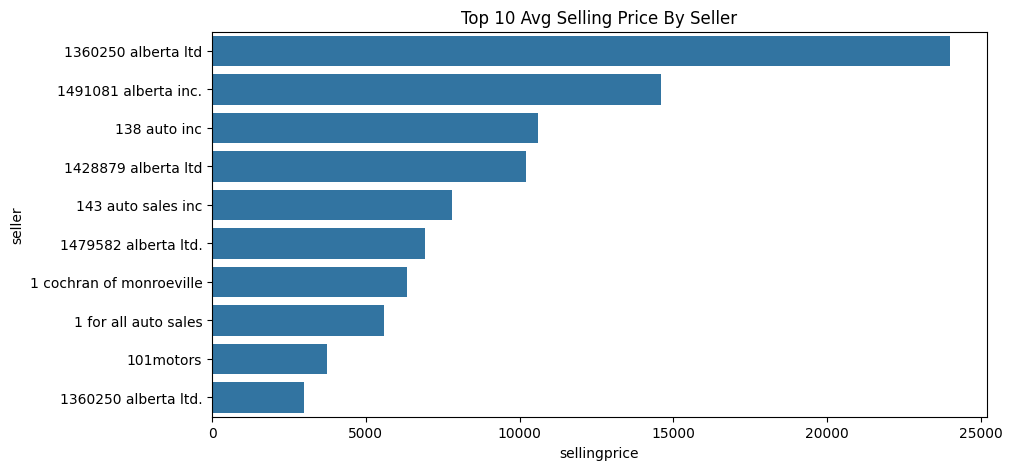

In [40]:
plt.figure(figsize=(10,5))
sns.barplot(data=avg_seller_sellingprice,
            x='sellingprice',
            y='seller')
plt.title('Top 10 Avg Selling Price By Seller')
plt.show()

9. Hypothesis Test 9

Business Question

Does exterior color significantly influence selling price?

Step 1 Prepare The Groups

In [41]:
groups=[
    group['sellingprice'].values
    for _, group in df.groupby('color')
]

f_stat, stats.f_oneway(*groups)
print(f_stat)
print(p)

5798.509148909637
0.0


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Step 2 Visualization

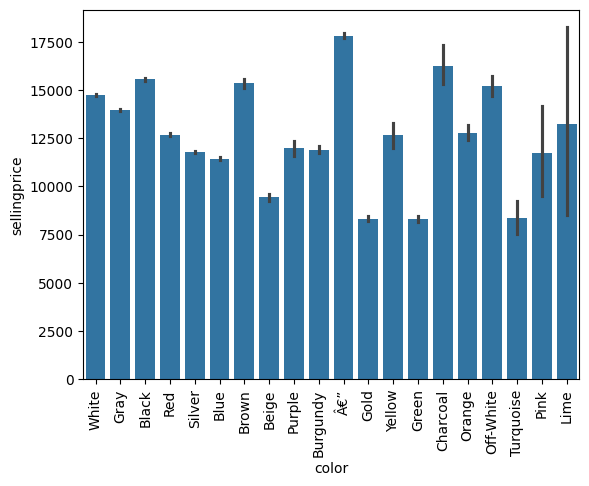

In [42]:
plt.Figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='color',
    y='sellingprice'
)
plt.xticks(rotation=90)
plt.show()

10. Hypothesis Test 10 

Business Question

Do different interior colors influence resale value?

Step 1 Prepare Groups

In [43]:
groups=[
    group['sellingprice'].values
    for _, group in df.groupby('interior')
]

f_stat, stats.f_oneway(*groups)
print(f_stat)
print(p)

5798.509148909637
0.0


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Step 2 visualization

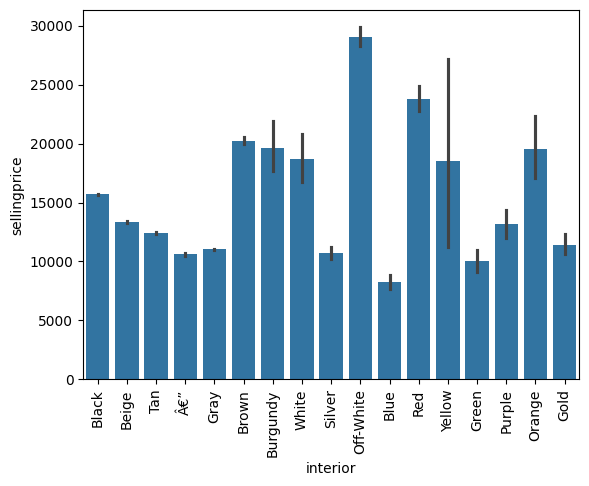

In [44]:
plt.Figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='interior',
    y='sellingprice'
)
plt.xticks(rotation=90)
plt.show()

11. Hypothesis Test 11 

Business Question

Is there a significant relationship between vehicle age and selling price?

Step 1 Calculate value of p

In [45]:
r,p =stats.pearsonr(
    df['vehicle_age'],
    df['sellingprice']
)

print(p)
print(r)

0.0
-0.5841383201052996


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Statistical Conclusion

There is a statistically significant negative correlation between vehicle age and vehicle selling price.

r = -0.5841

This indicates a moderate negative correlation.

This means:

As vehicle age increases, selling price decreases.
Vehicles with higher age generally have lower resale values.

Step 2 Effect Size

For a Pearson Correlation Test, the correlation coefficient (r) itself is the effect size.

|r|= 0.5841 indicates a large effect size

12. Hypothesis Test 12

Business Question:

Do different vehicle brands have significantly different price ratios?

Step 1 Create Groups

In [49]:
groups = [
    group['price_ratio'].dropna().values
    for _, group in df.groupby('make')
]
f_stat, stats.f_oneway(*groups)

print("F Statistic:",f_stat )
print("p-value:", p)

F Statistic: 5798.509148909637
p-value: 0.0


Decision

In [52]:
alpha = 0.05

if p < alpha:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Step 2 Visualization

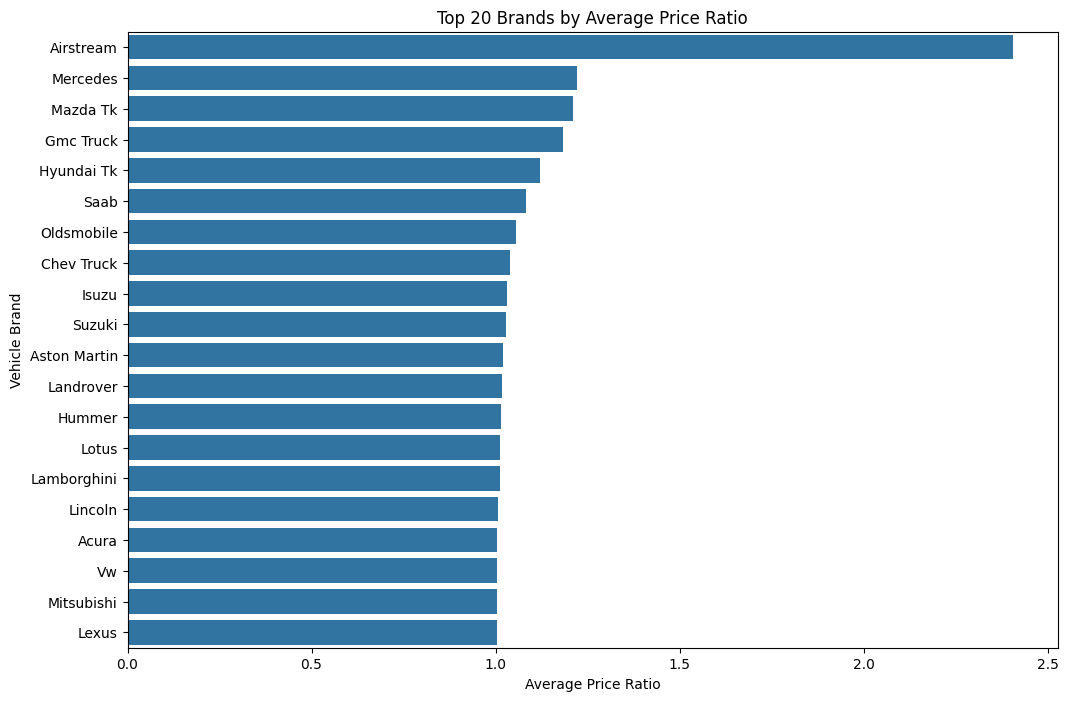

In [51]:
brand_ratio = (
    df.groupby('make')['price_ratio']
      .mean()
      .sort_values(ascending=False)
      .head(20)
      .reset_index()
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=brand_ratio,
    y='make',
    x='price_ratio'
)

plt.title("Top 20 Brands by Average Price Ratio")
plt.xlabel("Average Price Ratio")
plt.ylabel("Vehicle Brand")

plt.show()

Statistical Conclusion

There is sufficient statistical evidence to conclude that at least one vehicle brand has a significantly different average price ratio.

Business Insight

Some vehicle brands consistently sell above their Manheim Market Report (MMR), while others tend to sell at or below MMR. This suggests that brand reputation and market demand influence how closely the selling price aligns with the estimated market value.

13. Hypothesis Test 13

Business Question:

Are certain body types generally sold in better condition?

Step 1 Create groups

In [46]:
groups = [
    group['condition'].dropna().values
    for _, group in df.groupby('body')
]

f_stat, stats.f_oneway(*groups)
print(f_stat)
print(p)

5798.509148909637
0.0


Decision

Since the p-value < 0.05, reject the Null Hypothesis (H₀).

Statistical Conclusion

If significant:

There is sufficient statistical evidence to conclude that the average vehicle condition differs across body types.

Business Insight


SUVs and luxury vehicles may generally be sold in better condition than commercial vans or trucks, possibly due to different ownership patterns and maintenance practices.

Step 2 Visualization

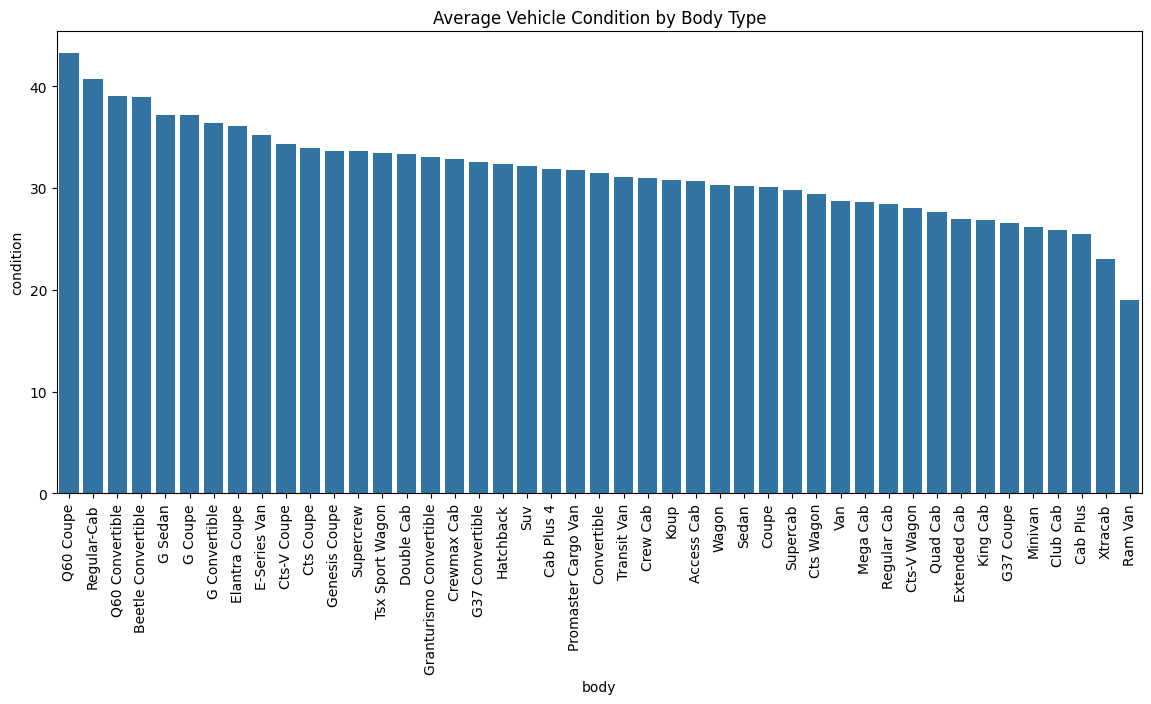

In [47]:
plt.figure(figsize=(14,6))

body_condition = (
    df.groupby('body')['condition']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

sns.barplot(
    data=body_condition,
    x='body',
    y='condition'
)

plt.xticks(rotation=90)
plt.title("Average Vehicle Condition by Body Type")
plt.show()